In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv("/kaggle/input/orbits-orbits-csv/orbits - orbits.csv")

In [3]:
df.head()

,Object Name,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,Classification,Hazardous
0,433 Eros,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,Amor Asteroid,False
1,719 Albert,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,Amor Asteroid,False
2,887 Alinda,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,Amor Asteroid,False
3,1036 Ganymed,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,Amor Asteroid,False
4,1221 Amor,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,Amor Asteroid,False


In [4]:
df.shape

(15635, 16)

In [5]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
lb1=LabelEncoder()
df['classification']=lb.fit_transform(df['Classification'])
df['hazardous']=lb1.fit_transform(df['Hazardous'])

df.head(50)

,Object Name,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,Classification,Hazardous,classification,hazardous
0,433 Eros,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,Amor Asteroid,False,0,0
1,719 Albert,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,Amor Asteroid,False,0,0
2,887 Alinda,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,Amor Asteroid,False,0,0
3,1036 Ganymed,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,Amor Asteroid,False,0,0
4,1221 Amor,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,Amor Asteroid,False,0,0
5,1566 Icarus,57800,1.0781,0.8269,22.8255,31.3830,88.0107,215.5288,0.1867,1.97,1.12,0.0345,100,16.90,Apollo Asteroid,True,2,1
6,1580 Betulia,57800,2.1973,0.4875,52.0908,159.4852,62.2921,191.9105,1.1260,3.27,3.26,0.1361,191,14.80,Amor Asteroid,False,0,0
7,1620 Geographos,57800,1.2453,0.3353,13.3375,276.8930,337.2080,104.1556,0.8277,1.66,1.39,0.0307,449,15.60,Apollo Asteroid,True,2,1
8,1627 Ivar,57800,1.8628,0.3966,8.4512,167.7730,133.1445,151.4603,1.1241,2.60,2.54,0.1124,635,13.20,Amor Asteroid,False,0,0
9,1685 Toro,54520,1.3673,0.4359,9.3807,127.0826,274.3396,48.6229,0.7713,1.96,1.60,0.0504,355,14.23,Apollo Asteroid,False,2,0


In [6]:
x=lb.inverse_transform([0,1,2,3])
print(x)

['Amor Asteroid' 'Apohele Asteroid' 'Apollo Asteroid' 'Aten Asteroid']


In [7]:
df.drop(['Object Name','Classification','Hazardous'],axis=1,inplace=True)
df.head()

,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,classification,hazardous
0,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,0,0
1,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,0,0
2,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,0,0
3,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,0,0
4,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,0,0


In [8]:
df=df.dropna()
df.shape

(15634, 15)

In [9]:
df.isnull().sum()

Epoch (TDB)                                 0
Orbit Axis (AU)                             0
Orbit Eccentricity                          0
Orbit Inclination (deg)                     0
Perihelion Argument (deg)                   0
Node Longitude (deg)                        0
Mean Anomoly (deg)                          0
Perihelion Distance (AU)                    0
Aphelion Distance (AU)                      0
Orbital Period (yr)                         0
Minimum Orbit Intersection Distance (AU)    0
Orbital Reference                           0
Asteroid Magnitude                          0
classification                              0
hazardous                                   0
dtype: int64

<Axes: >

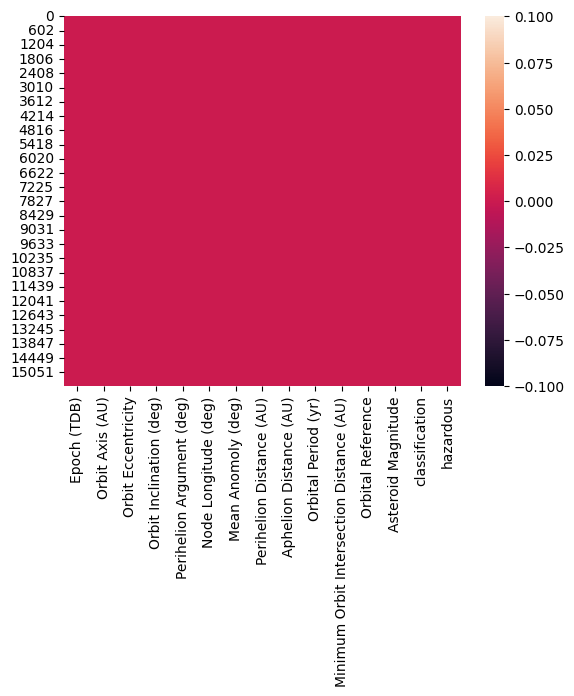

In [10]:
sns.heatmap(df.isnull())

In [11]:
df.drop(['Node Longitude (deg)'],axis=1,inplace=True)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


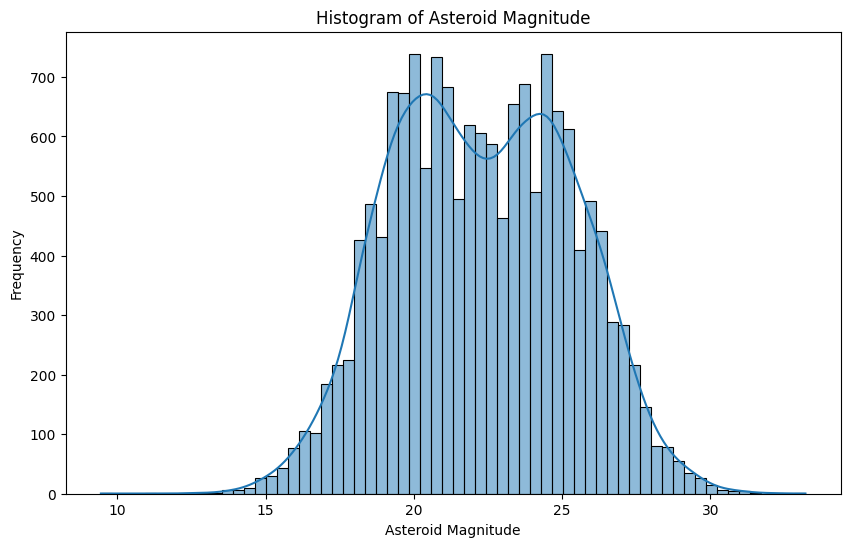

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Asteroid Magnitude'], kde=True) 
plt.title('Histogram of Asteroid Magnitude') 
plt.xlabel('Asteroid Magnitude') 
plt.ylabel('Frequency') 
plt.show()

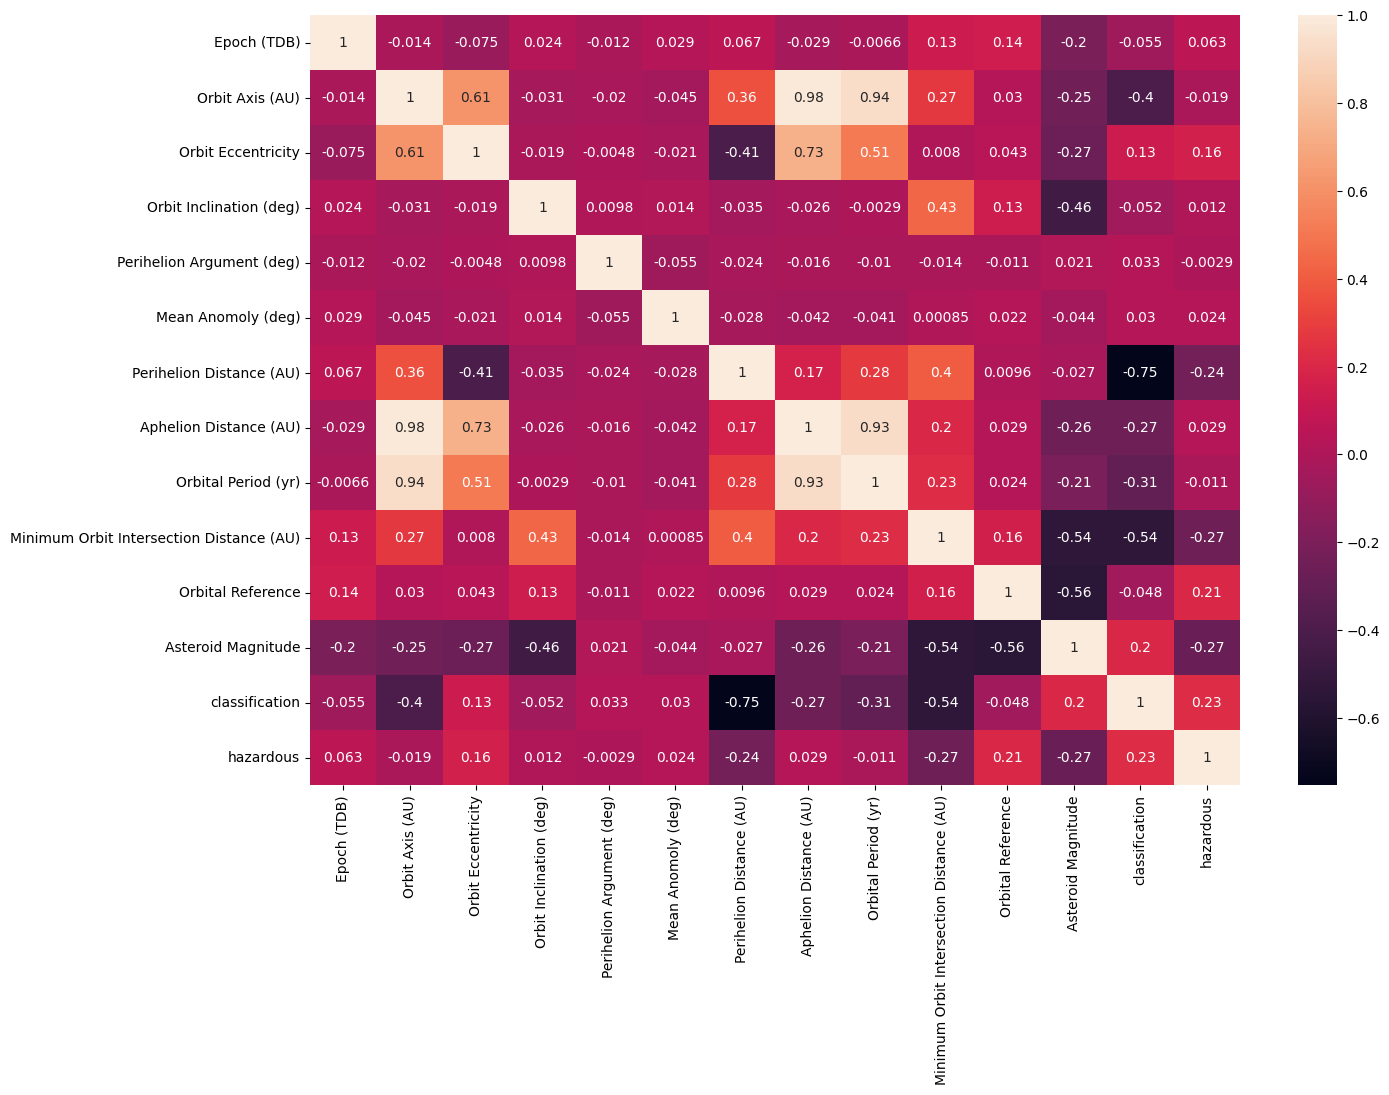

In [13]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.draw()

       Epoch (TDB)  Orbit Axis (AU)  Orbit Eccentricity  \
0            57800           1.4579              0.2226   
1            57800           2.6385              0.5479   
2            57800           2.4787              0.5671   
3            57800           2.6628              0.5338   
4            57800           1.9191              0.4356   
...            ...              ...                 ...   
15630        57800           1.4096              0.2946   
15631        57789           2.2612              0.4429   
15632        57800           1.5131              0.3275   
15633        57793           1.8815              0.4646   
15634        57800           2.8043              0.6672   

       Orbit Inclination (deg)  Perihelion Argument (deg)  Mean Anomoly (deg)  \
0                      10.8277                   178.8050            319.3111   
1                      11.5822                   156.1409            224.5535   
2                       9.3561                  

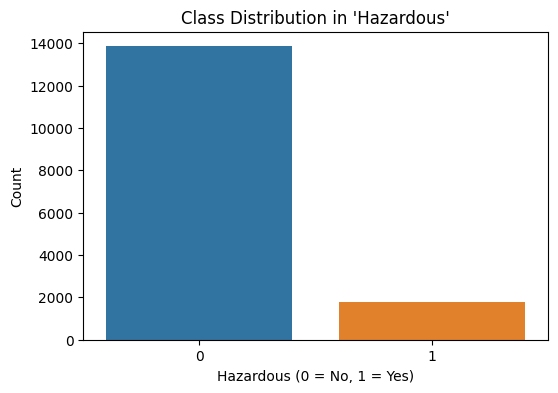

In [14]:
from sklearn.model_selection import train_test_split
x=df.drop(['hazardous'],axis=1)
y=df['hazardous']
print(x)
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution in 'Hazardous'")
plt.xlabel("Hazardous (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [15]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.4,random_state=42,stratify=y)
smote=SMOTE(sampling_strategy=0.5,random_state=42)
xtrain,ytrain=smote.fit_resample(xtrain,ytrain)
print(ytrain.value_counts())
smote2=SMOTE(sampling_strategy=0.3,random_state=42)
xtest,ytest=smote2.fit_resample(xtest,ytest)

hazardous
0    8313
1    4156
Name: count, dtype: int64


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)

In [17]:
rf.fit(xtrain,ytrain)

RandomForestClassifier(max_depth=10, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=100,random_state=42)
lr.fit(xtrain,ytrain)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [19]:
pred=rf.predict(xtest)
predlr=lr.predict(xtest)

In [20]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
a=accuracy_score(ytest,pred)
print(a)
print(confusion_matrix(ytest,pred))
print(classification_report(ytest,pred))

1.0
[[5542    0]
 [   0 1662]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5542
           1       1.00      1.00      1.00      1662

    accuracy                           1.00      7204
   macro avg       1.00      1.00      1.00      7204
weighted avg       1.00      1.00      1.00      7204



In [21]:
print(accuracy_score(ytest,predlr))

0.7529150471960022


In [22]:
import pandas as pd
feature_importances = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importances)

                                     Feature  Importance
9   Minimum Orbit Intersection Distance (AU)    0.367717
11                        Asteroid Magnitude    0.312314
10                         Orbital Reference    0.115092
6                   Perihelion Distance (AU)    0.096014
12                            classification    0.034051
3                    Orbit Inclination (deg)    0.020858
2                         Orbit Eccentricity    0.016735
0                                Epoch (TDB)    0.008771
7                     Aphelion Distance (AU)    0.007543
1                            Orbit Axis (AU)    0.005977
4                  Perihelion Argument (deg)    0.005758
8                        Orbital Period (yr)    0.005565
5                         Mean Anomoly (deg)    0.003605
